<a href="https://colab.research.google.com/github/reehabjahangir3-coder/THzScattering/blob/main/FFT_Teraflash.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fast Fourier Transformation of Terahertz Time-Domain Pulses into Frequency Domain with modified Blackmann Windowing



In [ ]:
#Import packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Data into a pandas framework

(Validate algorithm by comparing with Teraflash software FFT)


In [ ]:
pulse_df = pd.read_csv('/content/air_70ps.pulse.csv')
print("Pulse Data (first 5 rows):")
display(pulse_df.head())

#Comment out below line if no spectr.csv file is present

spectr_df = pd.read_csv('/content/air_70ps.spectr.csv')
print("\nSpectra Data (first 5 rows):")
display(spectr_df.head())

Pulse Data (first 5 rows):


,Time_abs/ps,Signal/nA
0,1100.00,0.078016
1,1100.05,0.033293
2,1100.10,0.001427
3,1100.15,-0.036264
4,1100.20,-0.076472



Spectra Data (first 5 rows):


,Frequency/GHz,Amplitude rel.,Phase
0,0.0,0.00681,0.00000
1,14.3,0.01460,0.96199
2,28.6,0.00911,2.38468
3,42.8,0.00867,4.73877
4,57.1,0.00762,5.67664


## 2. Apply a Windowing Function
### Measured signal starts/stops abruptly, and windowing reduces edge discontinuities, spectra leakages, improves numerical stability and allows isolation of useful part of signal.

### Modified Blackmann Window

Trapezoidal windows are a good choice for when true amplitude is important, minimally distorting main pulse and some degree of leakage reduction is needed.

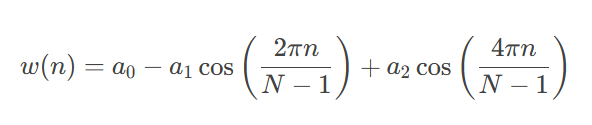

Tapered/Trapezoidal Window that builds an array with three regions: a rising edge, a flat middle and a falling edge.

### Define Blackmann Windowing Function

#### Parameters

1.    n(int) : Total Length of window
2.   relativewidth_start (float): fraction of n for taper at the start (0-1) {only tapers the first part}
3.   relativewidth_end (float): fraction of n for taper at the end (0-1)
{only tapers the last part}
4.   alpha = 0.16 (standard Blackman parameter)

The width of the window depends on the scan range: 50 ps needs a window of 2 ps (40 points), and longer ranges need a window of 10 ps (200 points) at the end (modify parameter 3 according to scan range)








In [ ]:
def modblackmanwindow(n, relativewidth_start, relativewidth_end):
    """
    Returns a modified Blackman window vector (values between 0 and 1).
    """

    alpha = 0.16
    w = np.ones(n)

    width_start = int(np.floor(relativewidth_start * n))
    width_end = int(np.floor(relativewidth_end * n))

    # Start taper
    if width_start >= 1:
        nrel = np.arange(0, width_start) / (2 * width_start - 1)
        w[:width_start] = 0.5 * (
            1 - alpha
            - np.cos(2 * np.pi * nrel)
            + alpha * np.cos(4 * np.pi * nrel)
        )

    # End taper
    if width_end >= 1:
        nrel = np.arange(width_end, 2 * width_end) / (2 * width_end - 1)
        w[n - width_end:] = 0.5 * (
            1 - alpha
            - np.cos(2 * np.pi * nrel)
            + alpha * np.cos(4 * np.pi * nrel)
        )

    return w

In [ ]:
# Extract time and signal data
pulse_df.columns = pulse_df.columns.str.strip() # Clean column names by stripping whitespace
time = pulse_df['Time_abs/ps'].values * 1e-12  # Convert ps to seconds
signal = pulse_df['Signal/nA'].values

# Number of sample points
N = len(signal)
# Sample spacing
T = time[1] - time[0]

# Apply modified Blackman window using the defined function
# 2 ps/ 40 points for 50 ps scan range and 10 ps/ 200 points for longer scan ranges - end taper
start_window_duration_s = 1e-12 # From previous context
end_window_duration_s = 10e-12  # From previous context

#Define width
num_samples_start_window = int(start_window_duration_s / T)
num_samples_end_window = int(end_window_duration_s / T)

#Width of modified Blackman window is adapted to scan range -
relativewidth_start = num_samples_start_window / N
relativewidth_end = num_samples_end_window / N

window = modblackmanwindow(N, relativewidth_start, relativewidth_end)

# Apply the window to the signal
signal_windowed = signal * window

## 3. Perform FFT on Pulse Data

Fourier Transform (FT) related the time domain of a signal to its frequency domain, where the frequency domain contains the information about the sinusoids (amplitude, frequency, phase) that construct the signal.

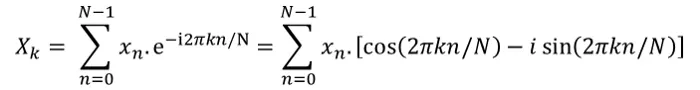




**Euler's formula**

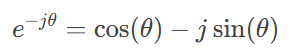

where  
* X[n] = time-domain values
* X[k] = frequency domain values
* N = number of sampling points
* T = Sample spacing
* signal_windowed = Modified Blackmann Window


**Frequency domain signal is complex-valued**

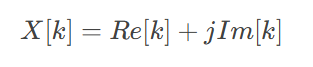

####After FFT, Magnitude of frequency component:

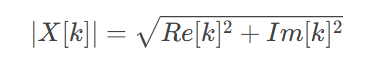

#### Converting Magnitude to Actual Amplitude (FFT is a sum)

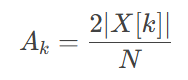

#### After FFT, Phase of frequency component

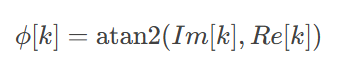

In [ ]:
from scipy.fft import fft, fftfreq

# Perform FFT on the windowed signal
yf = fft(signal_windowed)
# Calculate frequency from sampling frequency and FFT size
xf = fftfreq(N, T)

# Real signal splits its energy between positive frequencies (+f) and negative frequency (-f): when plotting a single-sided spectrum, we keep only the positive f
positive_frequencies = xf[xf >= 0]
positive_yf = yf[xf >= 0]

# Calculate amplitude (magnitude)
amplitude = np.abs(positive_yf)

# Normalize amplitude: Divide by N for DC component, 2/N for others (for single-sided spectrum) {DFT is a  sum}
amplitude[0] = amplitude[0] / N  # DC component
amplitude[1:] = 2 * amplitude[1:] / N # Non-DC components

# Calculate phase (radians) - output is in [-pi, pi]
phase_radians = np.arctan2(positive_yf.imag, positive_yf.real)

# Unwrap phase (radians)
phase_unwrapped_radians = np.unwrap(phase_radians)

#Make phase positive and subtract/add 2*PI for since FFT sometimes does not distinguish correctly
phase_unwrapped_radians = -(phase_unwrapped_radians - 2*np.pi)

# Convert frequency to GHz
frequency_ghz = positive_frequencies / 1e9

amplitude = amplitude/12.459526933307043

# Create a DataFrame for FFT results
fft_df = pd.DataFrame({
    'Frequency/GHz': frequency_ghz,
    'Amplitude': amplitude,
    'Phase (unwrapped rad)': phase_unwrapped_radians # Unwrapped phase in radians
})

print("FFT Results (first 5 rows):")
display(fft_df.head())

FFT Results (first 5 rows):


,Frequency/GHz,Amplitude,Phase (unwrapped rad)
0,0.000000,0.045994,9.424778
1,14.275517,0.029506,6.703472
2,28.551035,0.012624,5.027819
3,42.826552,0.015598,4.033184
4,57.102070,0.022032,6.648321


**Record the amplitude of the reference to calculate amplitude relative to samples**

In [ ]:
#print(fft_df['Amplitude'].max())

12.459526933307043


## 4. Normalisation for reference
1. Interpolate the calculated FFT amplitude to the frequency points of the reference spectrum
2. Normalize its maximum value to 1, but only for reference. For samples, calculate the relative amplitude instead.

Relative amplitude = FFT_amplitude of sample/ Max FFT_amplitude of reference

In [ ]:
fft_df['Amplitude (normalized)'] = fft_df['Amplitude'] / fft_df['Amplitude'].max()

print("FFT Results with Normalized Amplitude (first 5 rows):")
display(fft_df.head())

FFT Results with Normalized Amplitude (first 5 rows):


,Frequency/GHz,Amplitude,Phase (unwrapped rad),Amplitude (normalized)
0,0.000000,0.045994,9.424778,0.045994
1,14.275517,0.029506,6.703472,0.029506
2,28.551035,0.012624,5.027819,0.012624
3,42.826552,0.015598,4.033184,0.015598
4,57.102070,0.022032,6.648321,0.022032


## 5. Plot calculated FFT Amplitude and Teraflash processed Amplitude

Interpolate to reference frequencies (can also round up?)

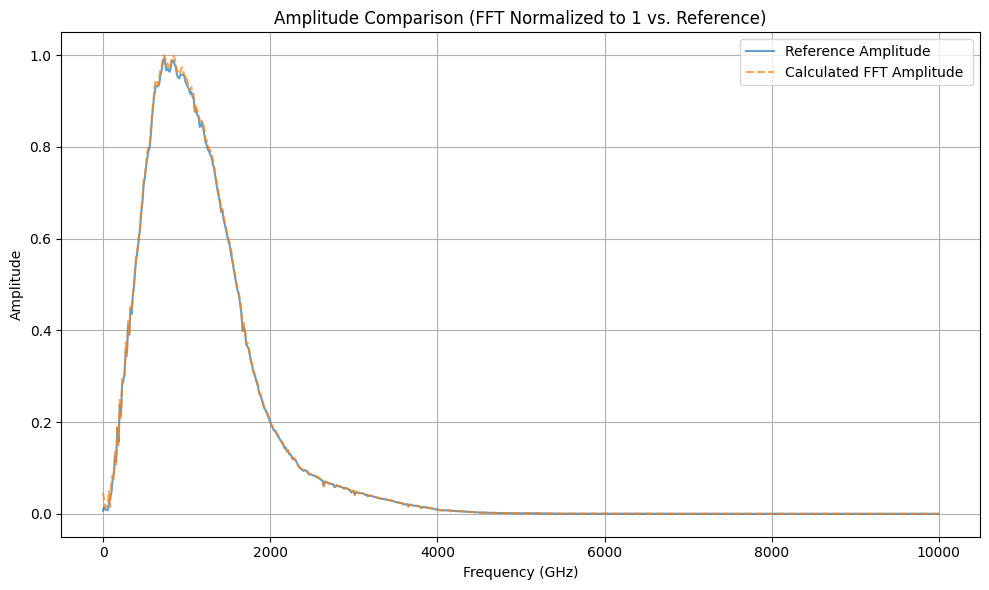

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d

# Get the frequency points from the reference spectrum (spectr_df)
reference_frequencies = spectr_df['Frequency/GHz']

# Create an interpolation function for the normalized FFT amplitude

f_interp = interp1d(
    fft_df['Frequency/GHz'],
    fft_df['Amplitude (normalized)'],
    kind='nearest-up',
    bounds_error=False, # Allow extrapolation/fill for out-of-bounds
    fill_value=0 # Fill with 0 for points outside the FFT frequency range
)

# Interpolate the FFT amplitude to the reference frequency points
interpolated_fft_amplitude = f_interp(reference_frequencies)

# Create the comparison DataFrame
normalized_comparison_df = pd.DataFrame({
    'Frequency/GHz': reference_frequencies,
    'Reference Amplitude': spectr_df[' Amplitude rel.'],
    'FFT Amplitude (Normalized to 1)': interpolated_fft_amplitude
})

plt.figure(figsize=(10, 6))
sns.lineplot(x='Frequency/GHz', y='Reference Amplitude', data=normalized_comparison_df, label='Reference Amplitude', alpha=0.7)
sns.lineplot(x='Frequency/GHz', y='FFT Amplitude (Normalized to 1)', data=normalized_comparison_df, label='Calculated FFT Amplitude ', alpha=0.7, linestyle='--')
plt.title('Amplitude Comparison (FFT Normalized to 1 vs. Reference)')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Plot calculated FFT phase and Teraflash processed Phase

Splitting at very low frequencies and higher frequencies is expected due to the measurement approaching the noise floor of the experiment

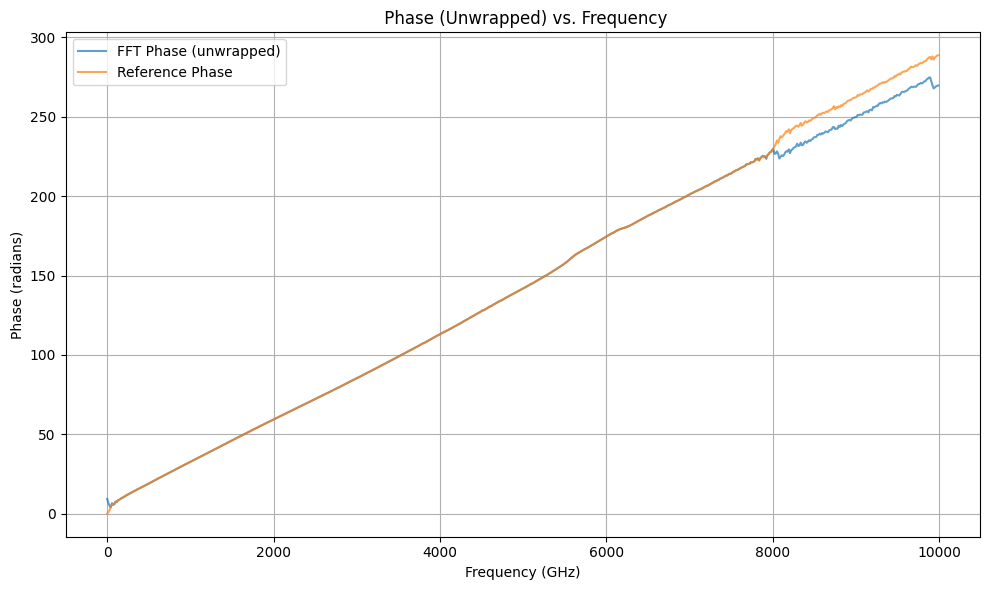

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(x='Frequency/GHz', y='Phase (unwrapped rad)', data=fft_df, label='FFT Phase (unwrapped)', alpha=0.7)
sns.lineplot(x='Frequency/GHz', y=' Phase', data=spectr_df, label='Reference Phase', alpha=0.7)
plt.title(' Phase (Unwrapped) vs. Frequency')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Phase (radians)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##6. Compare the splitting magnitudes for the reference and calculated FFT

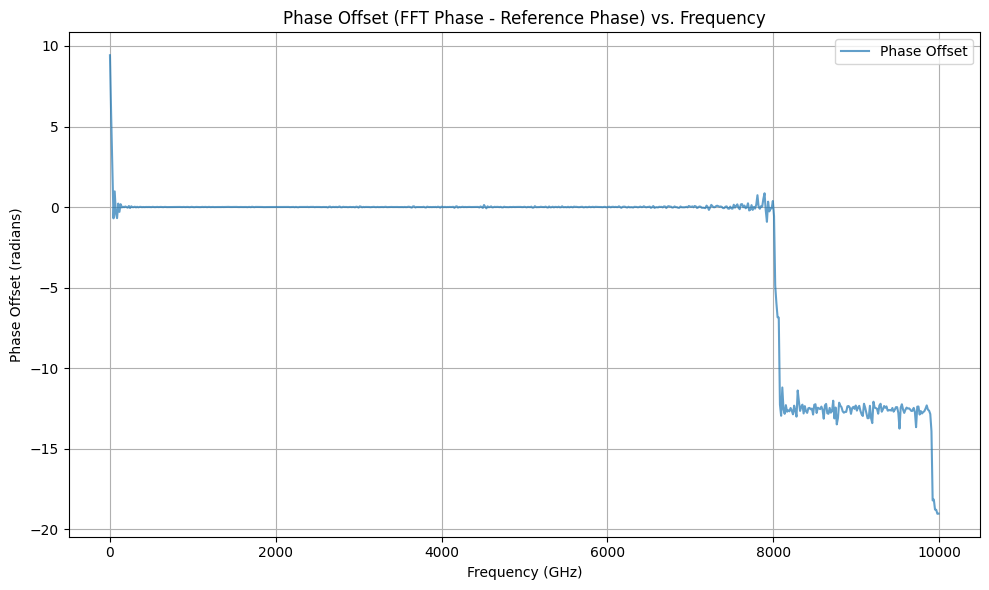

In [ ]:
from scipy.interpolate import interp1d

# Get the frequency points from the reference spectrum (spectr_df)
reference_frequencies = spectr_df['Frequency/GHz']

# Create an interpolation function for the unwrapped FFT phase
f_interp_phase = interp1d(
    fft_df['Frequency/GHz'],
    fft_df['Phase (unwrapped rad)'],
    kind='linear',
    bounds_error=False, # Allow extrapolation/fill for out-of-bounds
    fill_value='extrapolate' # Extrapolate for points outside the FFT frequency range
)

# Interpolate the FFT phase to the reference frequency points
interpolated_fft_phase = f_interp_phase(reference_frequencies)

# Create a DataFrame for phase comparison
phase_comparison_df = pd.DataFrame({
    'Frequency/GHz': reference_frequencies,
    'Reference Phase': spectr_df[' Phase'],
    'FFT Phase (Unwrapped)': interpolated_fft_phase
})

# Calculate the phase offset
phase_comparison_df['Phase Offset (rad)'] = phase_comparison_df['FFT Phase (Unwrapped)'] - phase_comparison_df['Reference Phase']

plt.figure(figsize=(10, 6))
sns.lineplot(x='Frequency/GHz', y='Phase Offset (rad)', data=phase_comparison_df, label='Phase Offset', alpha=0.7)
plt.title('Phase Offset (FFT Phase - Reference Phase) vs. Frequency')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Phase Offset (radians)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
if 'fft_df' not in locals() and 'fft_df' not in globals():
    print("Error: 'fft_df' DataFrame is not defined. Please ensure the cell that performs the FFT (cell '71a4fb82') has been executed before running this cell.")
else:
    # Include 'Amplitude (normalized)' in the columns to save
    output_df = fft_df[['Frequency/GHz', 'Amplitude (normalized)', 'Phase (unwrapped rad)']].copy()
    output_df.to_csv('fft_results.csv', index=False)
    print('FFT results saved to fft_results.csv')

FFT results saved to fft_results.csv
